# IoT Environmental Monitoring & Anomaly Detection System

A Python-based project for analyzing simulated environmental sensor data
and detecting potentially hazardous conditions using threshold-based analysis.

## Imports

In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
random.seed(42)

## 1. Generate Simulated Sensor Data

In [2]:

sensor_data=[]
for i in range(20):
  temperature= random.uniform(20,40)
  humidity = random.randint(30,80)
  aqi =random.randint(30,150)
  sensor_data.append([temperature,humidity,aqi])
print("Reading", i+1)
print("temperature:",round(temperature,2),"°C")
print("humidity:",humidity,"%")
print("aqi:",aqi)
print("----------------")
print("Done! 20 VALUES GENERATED")

Reading 20
temperature: 23.85 °C
humidity: 34 %
aqi: 35
----------------
Done! 20 VALUES GENERATED


## 2. Create DataFrame

In [3]:

pd.DataFrame()
df= pd.DataFrame(sensor_data, columns=["Temperature","Humidity","AQI"])
df

,Temperature,Humidity,AQI
0,32.788536,31,124
1,25.500586,44,47
2,34.729424,73,124
3,37.843591,35,105
4,28.438436,31,41
5,24.372759,62,107
6,20.530719,42,121
7,32.997689,64,83
8,24.408812,67,65
9,36.188609,30,127


## 3. Explore the Sensor Data

In [4]:
df.head()


,Temperature,Humidity,AQI
0,32.788536,31,124
1,25.500586,44,47
2,34.729424,73,124
3,37.843591,35,105
4,28.438436,31,41


In [5]:
df.shape

(20, 3)

In [6]:
df.mean()
df.max()
df.min()

,0
Temperature,20.530719
Humidity,30.000000
AQI,35.000000


## 4. Detect Temperature Anomalies

In [7]:
def check_temperature(temp):
  if temp>35:
    return "Anamoly"
  else:
    return "Normal"

In [8]:
df["Temperature_Status"] = df["Temperature"].apply(check_temperature)


### Temperature Anomaly Results

In [9]:
df

,Temperature,Humidity,AQI,Temperature_Status
0,32.788536,31,124,Normal
1,25.500586,44,47,Normal
2,34.729424,73,124,Normal
3,37.843591,35,105,Anamoly
4,28.438436,31,41,Normal
5,24.372759,62,107,Normal
6,20.530719,42,121,Normal
7,32.997689,64,83,Normal
8,24.408812,67,65,Normal
9,36.188609,30,127,Anamoly


In [10]:
def check_aqi(aqi):
    if aqi > 100:
        return "Anomaly"
    else:
        return "Normal"

In [11]:
df["AQI_Status"] = df["AQI"].apply(check_aqi)

### AQI Anomaly Detection

In [12]:
df

,Temperature,Humidity,AQI,Temperature_Status,AQI_Status
0,32.788536,31,124,Normal,Anomaly
1,25.500586,44,47,Normal,Normal
2,34.729424,73,124,Normal,Anomaly
3,37.843591,35,105,Anamoly,Anomaly
4,28.438436,31,41,Normal,Normal
5,24.372759,62,107,Normal,Anomaly
6,20.530719,42,121,Normal,Anomaly
7,32.997689,64,83,Normal,Normal
8,24.408812,67,65,Normal,Normal
9,36.188609,30,127,Anamoly,Anomaly


In [13]:
def check_humidity(humidity):
    if humidity > 80:
        return "Anomaly"
    else:
        return "Normal"

In [14]:
df["Humidity_Status"] = df["Humidity"].apply(check_humidity)

### Humididty Anomaly Detection

In [15]:
df

,Temperature,Humidity,AQI,Temperature_Status,AQI_Status,Humidity_Status
0,32.788536,31,124,Normal,Anomaly,Normal
1,25.500586,44,47,Normal,Normal,Normal
2,34.729424,73,124,Normal,Anomaly,Normal
3,37.843591,35,105,Anamoly,Anomaly,Normal
4,28.438436,31,41,Normal,Normal,Normal
5,24.372759,62,107,Normal,Anomaly,Normal
6,20.530719,42,121,Normal,Anomaly,Normal
7,32.997689,64,83,Normal,Normal,Normal
8,24.408812,67,65,Normal,Normal,Normal
9,36.188609,30,127,Anamoly,Anomaly,Normal


In [16]:
def overall_status(row):
    if (row["Temperature_Status"] == "Anomaly" or
        row["Humidity_Status"] == "Anomaly" or
        row["AQI_Status"] == "Anomaly"):
        return "Hazardous"
    else:
        return "Normal"

### 5.Determine Overall Environmental Status

In [17]:
df["Environmental_Status"] = df.apply(overall_status, axis=1)

In [18]:
df

,Temperature,Humidity,AQI,Temperature_Status,AQI_Status,Humidity_Status,Environmental_Status
0,32.788536,31,124,Normal,Anomaly,Normal,Hazardous
1,25.500586,44,47,Normal,Normal,Normal,Normal
2,34.729424,73,124,Normal,Anomaly,Normal,Hazardous
3,37.843591,35,105,Anamoly,Anomaly,Normal,Hazardous
4,28.438436,31,41,Normal,Normal,Normal,Normal
5,24.372759,62,107,Normal,Anomaly,Normal,Hazardous
6,20.530719,42,121,Normal,Anomaly,Normal,Hazardous
7,32.997689,64,83,Normal,Normal,Normal,Normal
8,24.408812,67,65,Normal,Normal,Normal,Normal
9,36.188609,30,127,Anamoly,Anomaly,Normal,Hazardous


In [19]:
df["Environmental_Status"].value_counts()

,count
Environmental_Status,
Normal,12
Hazardous,8


## 6. Visualize Sensor Data

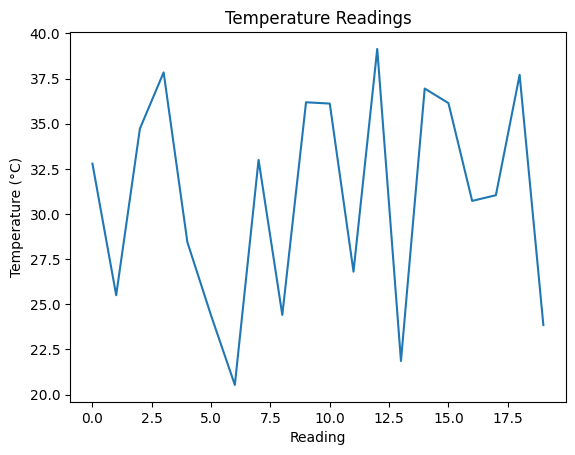

In [20]:


plt.plot(df["Temperature"])
plt.xlabel("Reading")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Readings")
plt.show()

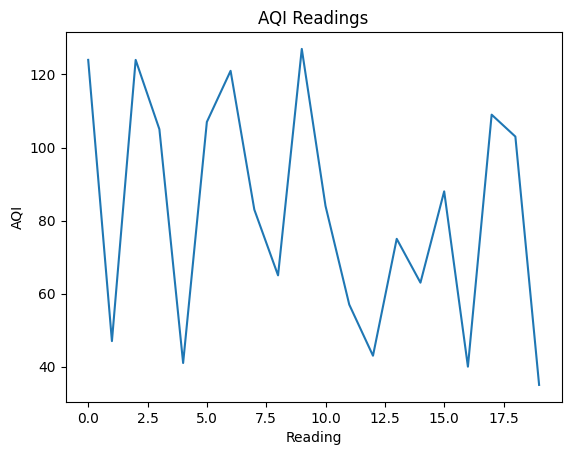

In [21]:
plt.plot(df["AQI"])
plt.xlabel("Reading")
plt.ylabel("AQI")
plt.title("AQI Readings")
plt.show()

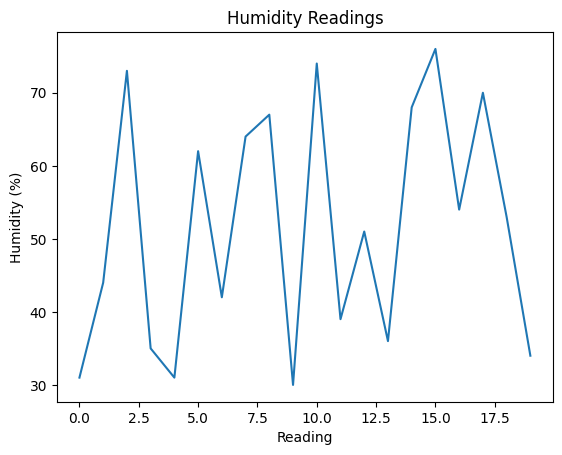

In [22]:
plt.plot(df["Humidity"])
plt.xlabel("Reading")
plt.ylabel("Humidity (%)")
plt.title("Humidity Readings")
plt.show()

## 7. Save and Load Sensor Data

In [23]:
df.to_csv("sensor_data.csv", index=False)

In [24]:
df_check = pd.read_csv("sensor_data.csv")
df_check.head()

,Temperature,Humidity,AQI,Temperature_Status,AQI_Status,Humidity_Status,Environmental_Status
0,32.788536,31,124,Normal,Anomaly,Normal,Hazardous
1,25.500586,44,47,Normal,Normal,Normal,Normal
2,34.729424,73,124,Normal,Anomaly,Normal,Hazardous
3,37.843591,35,105,Anamoly,Anomaly,Normal,Hazardous
4,28.438436,31,41,Normal,Normal,Normal,Normal


## 8. Analyze Detected Anomalies

In [25]:
temperature_anamolies=(df["Temperature_Status"]=="Anomaly").sum()
humidity_anamolies=(df["Humidity_Status"]=="Anomaly").sum()
aqi_anamolies=(df["AQI_Status"]=="Anomaly").sum()
print("Total readings:",len(df))
print("Temperature_anamolies:",temperature_anamolies)
print("Humidity_anamolies:",humidity_anamolies)
print("AQI_anamolies:",aqi_anamolies)

Total readings: 20
Temperature_anamolies: 0
Humidity_anamolies: 0
AQI_anamolies: 8


### Anomaly Percentages

In [26]:
temperature_percentage=(temperature_anamolies/len(df))*100
humidity_percentage=(humidity_anamolies/len(df))*100
aqi_percentage=(aqi_anamolies/len(df))*100
print("Temperature_percentage:",round(temperature_percentage,2),"%")
print("Humidity_percentage:",round(humidity_percentage,2),"%")
print("AQI_percentage:",round(aqi_percentage,2),"%")

Temperature_percentage: 0.0 %
Humidity_percentage: 0.0 %
AQI_percentage: 40.0 %


### 9.Environmental Status Distribution

In [27]:
status_percentage = df["Environmental_Status"].value_counts(normalize=True) * 100
print(status_percentage)

Environmental_Status
Normal       60.0
Hazardous    40.0
Name: proportion, dtype: float64


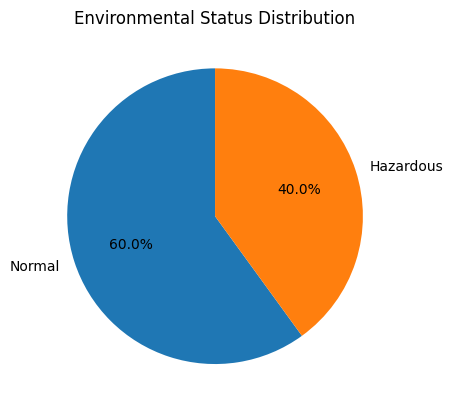

In [28]:


status_counts = df["Environmental_Status"].value_counts()

plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Environmental Status Distribution")
plt.show()

### 10.Hazardous Readings

In [29]:
hazardous_readings = df[df["Environmental_Status"] == "Hazardous"]

hazardous_readings

,Temperature,Humidity,AQI,Temperature_Status,AQI_Status,Humidity_Status,Environmental_Status
0,32.788536,31,124,Normal,Anomaly,Normal,Hazardous
2,34.729424,73,124,Normal,Anomaly,Normal,Hazardous
3,37.843591,35,105,Anamoly,Anomaly,Normal,Hazardous
5,24.372759,62,107,Normal,Anomaly,Normal,Hazardous
6,20.530719,42,121,Normal,Anomaly,Normal,Hazardous
9,36.188609,30,127,Anamoly,Anomaly,Normal,Hazardous
17,31.040813,70,109,Normal,Anomaly,Normal,Hazardous
18,37.709035,53,103,Anamoly,Anomaly,Normal,Hazardous


## 11. Final Analysis Summary

In [30]:
summary = {
    "Total readings": len(df),
    "Normal readings": (df["Environmental_Status"] == "Normal").sum(),
    "Hazardous readings": (df["Environmental_Status"] == "Hazardous").sum(),
    "Normal percentage": (df["Environmental_Status"] == "Normal").mean() * 100,
    "Hazardous percentage": (df["Environmental_Status"] == "Hazardous").mean() * 100,
    "Temperature anomalies": (df["Temperature_Status"] == "Anomaly").sum(),
    "Humidity anomalies": (df["Humidity_Status"] == "Anomaly").sum(),
    "AQI anomalies": (df["AQI_Status"] == "Anomaly").sum()
}

summary

{'Total readings': 20,
 'Normal readings': np.int64(12),
 'Hazardous readings': np.int64(8),
 'Normal percentage': np.float64(60.0),
 'Hazardous percentage': np.float64(40.0),
 'Temperature anomalies': np.int64(0),
 'Humidity anomalies': np.int64(0),
 'AQI anomalies': np.int64(8)}

## 12. Conclusion

This project demonstrates how simulated environmental sensor data can be
generated, stored, analyzed, and visualized using Python. Threshold-based
anomaly detection was implemented for temperature, humidity, and AQI values,
and the readings were classified as Normal or Hazardous. The project also
includes data visualization, CSV storage, and summary analysis.

